In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8")
pd.set_option('display.float_format', lambda x: '%.5f' % x)

In [2]:
data  = pd.read_csv("EURUSD_M15_2019-2025.csv", parse_dates = ['time'], index_col = 'time')

In [3]:
data = data[:'2023-12-31']

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 124428 entries, 2019-01-01 22:00:00 to 2023-12-29 21:45:00
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   price   124428 non-null  float64
 1   spread  124428 non-null  float64
dtypes: float64(2)
memory usage: 2.8 MB


In [5]:
data['returns'] = np.log(data['price'] / data['price'].shift(1))

In [6]:
window = 50

In [7]:
df = data.copy()
df["dir"] = np.where(df["returns"] > 0, 1, 0)
df["sma"] = df['price'].rolling(window).mean() - df['price'].rolling(150).mean()
df["boll"] = (df['price'] - df['price'].rolling(window).mean()) / df['price'].rolling(window).std()
df["min"] = df['price'].rolling(window).min() / df['price'] - 1
df["max"] = df['price'].rolling(window).max() / df['price'] - 1
df["mom"] = df["returns"].rolling(3).mean()
df["vol"] = df["returns"].rolling(window).std()
df.dropna(inplace = True)

In [8]:
df

,price,spread,returns,dir,sma,boll,min,max,mom,vol
time,,,,,,,,,,
2019-01-03 11:15:00,1.13547,0.00014,-0.00017,0,-0.00337,-0.41014,-0.00372,0.00244,-0.00045,0.00063
2019-01-03 11:30:00,1.13498,0.00013,-0.00043,0,-0.00328,-0.76137,-0.00329,0.00287,-0.00055,0.00060
2019-01-03 11:45:00,1.13416,0.00015,-0.00072,0,-0.00320,-1.34227,-0.00257,0.00360,-0.00044,0.00061
2019-01-03 12:00:00,1.13437,0.00014,0.00019,1,-0.00310,-1.23208,-0.00275,0.00341,-0.00032,0.00061
2019-01-03 12:15:00,1.13482,0.00013,0.00040,1,-0.00295,-1.09565,-0.00099,0.00301,-0.00005,0.00054
...,...,...,...,...,...,...,...,...,...,...
2023-12-29 20:45:00,1.10411,0.00016,-0.00018,0,-0.00178,-1.62916,-0.00001,0.00346,-0.00026,0.00059
2023-12-29 21:00:00,1.10358,0.00017,-0.00048,0,-0.00177,-2.02317,0.00000,0.00394,-0.00036,0.00057
2023-12-29 21:15:00,1.10366,0.00015,0.00007,1,-0.00177,-1.83452,-0.00007,0.00387,-0.00020,0.00057


In [9]:
lags = 5

In [10]:
col = []
features = ["sma", "boll", "min", "max", "mom", "vol","dir"]
for feature in features:
    for lag in range(1, lags + 1):
        col.append(f"{feature}_lag{lag}")
        df[f"{feature}_lag{lag}"] = df[feature].shift(lag)
df.dropna(inplace = True)

In [11]:
df

,price,spread,returns,dir,sma,boll,min,max,mom,vol,...,vol_lag1,vol_lag2,vol_lag3,vol_lag4,vol_lag5,dir_lag1,dir_lag2,dir_lag3,dir_lag4,dir_lag5
time,,,,,,,,,,,,,,,,,,,,,
2019-01-03 12:30:00,1.13535,0.00012,0.00047,1,-0.00284,-0.71579,-0.00125,0.00255,0.00035,0.00045,...,0.00054,0.00061,0.00061,0.00060,0.00063,1.00000,1.00000,0.00000,0.00000,0.00000
2019-01-03 12:45:00,1.13436,0.00012,-0.00087,0,-0.00276,-1.56972,-0.00038,0.00342,-0.00000,0.00046,...,0.00045,0.00054,0.00061,0.00061,0.00060,1.00000,1.00000,1.00000,0.00000,0.00000
2019-01-03 13:00:00,1.13483,0.00044,0.00041,1,-0.00266,-1.21306,-0.00075,0.00300,0.00000,0.00046,...,0.00046,0.00045,0.00054,0.00061,0.00061,0.00000,1.00000,1.00000,1.00000,0.00000
2019-01-03 13:15:00,1.13506,0.00021,0.00020,1,-0.00257,-1.06133,-0.00079,0.00280,-0.00009,0.00046,...,0.00046,0.00046,0.00045,0.00054,0.00061,1.00000,0.00000,1.00000,1.00000,1.00000
2019-01-03 13:30:00,1.13574,0.00013,0.00060,1,-0.00248,-0.47358,-0.00139,0.00220,0.00041,0.00046,...,0.00046,0.00046,0.00046,0.00045,0.00054,1.00000,1.00000,0.00000,1.00000,1.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-29 20:45:00,1.10411,0.00016,-0.00018,0,-0.00178,-1.62916,-0.00001,0.00346,-0.00026,0.00059,...,0.00059,0.00061,0.00060,0.00059,0.00060,0.00000,0.00000,1.00000,0.00000,1.00000
2023-12-29 21:00:00,1.10358,0.00017,-0.00048,0,-0.00177,-2.02317,0.00000,0.00394,-0.00036,0.00057,...,0.00059,0.00059,0.00061,0.00060,0.00059,0.00000,0.00000,0.00000,1.00000,0.00000
2023-12-29 21:15:00,1.10366,0.00015,0.00007,1,-0.00177,-1.83452,-0.00007,0.00387,-0.00020,0.00057,...,0.00057,0.00059,0.00059,0.00061,0.00060,0.00000,0.00000,0.00000,0.00000,1.00000


In [12]:
len(col)

35

In [13]:
len(df)

124274

In [14]:
# split = int(len(df)*0.66)
# split

In [15]:
train = df.loc["2021-01-01":"2022-12-31"].copy()
train

,price,spread,returns,dir,sma,boll,min,max,mom,vol,...,vol_lag1,vol_lag2,vol_lag3,vol_lag4,vol_lag5,dir_lag1,dir_lag2,dir_lag3,dir_lag4,dir_lag5
time,,,,,,,,,,,,,,,,,,,,,
2021-01-03 22:00:00,1.22333,0.00100,0.00145,1,-0.00277,-0.52064,-0.00190,0.00439,0.00035,0.00051,...,0.00047,0.00047,0.00049,0.00050,0.00048,0.00000,0.00000,0.00000,1.00000,0.00000
2021-01-03 22:15:00,1.22387,0.00100,0.00044,1,-0.00284,-0.29838,-0.00235,0.00395,0.00054,0.00050,...,0.00051,0.00047,0.00047,0.00049,0.00050,1.00000,0.00000,0.00000,0.00000,1.00000
2021-01-03 22:30:00,1.22348,0.00039,-0.00032,0,-0.00292,-0.41355,-0.00203,0.00427,0.00052,0.00050,...,0.00050,0.00051,0.00047,0.00047,0.00049,1.00000,1.00000,0.00000,0.00000,0.00000
2021-01-03 22:45:00,1.22342,0.00063,-0.00005,0,-0.00300,-0.40772,-0.00198,0.00432,0.00002,0.00050,...,0.00050,0.00050,0.00051,0.00047,0.00047,0.00000,1.00000,1.00000,0.00000,0.00000
2021-01-03 23:00:00,1.22398,0.00025,0.00046,1,-0.00306,-0.16589,-0.00243,0.00386,0.00003,0.00051,...,0.00050,0.00050,0.00050,0.00051,0.00047,0.00000,0.00000,1.00000,1.00000,0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-12-30 20:45:00,1.07055,0.00020,0.00027,1,0.00188,1.28481,-0.00528,0.00054,0.00020,0.00071,...,0.00071,0.00072,0.00073,0.00073,0.00072,0.00000,1.00000,0.00000,0.00000,1.00000
2022-12-30 21:00:00,1.07039,0.00020,-0.00015,0,0.00189,1.14211,-0.00513,0.00069,0.00003,0.00070,...,0.00071,0.00071,0.00072,0.00073,0.00073,1.00000,0.00000,1.00000,0.00000,0.00000
2022-12-30 21:15:00,1.07045,0.00018,0.00006,1,0.00190,1.13027,-0.00518,0.00064,0.00006,0.00070,...,0.00070,0.00071,0.00071,0.00072,0.00073,0.00000,1.00000,0.00000,1.00000,0.00000


In [16]:
test = df.loc["2023-01-01":"2023-12-31"].copy()
test

,price,spread,returns,dir,sma,boll,min,max,mom,vol,...,vol_lag1,vol_lag2,vol_lag3,vol_lag4,vol_lag5,dir_lag1,dir_lag2,dir_lag3,dir_lag4,dir_lag5
time,,,,,,,,,,,,,,,,,,,,,
2023-01-01 23:00:00,1.06998,0.00100,-0.00038,0,0.00201,0.74330,-0.00475,0.00107,-0.00015,0.00069,...,0.00068,0.00070,0.00070,0.00070,0.00071,1.00000,0.00000,1.00000,0.00000,1.00000
2023-01-01 23:15:00,1.07000,0.00100,0.00002,1,0.00205,0.72739,-0.00477,0.00106,-0.00008,0.00068,...,0.00069,0.00068,0.00070,0.00070,0.00070,0.00000,1.00000,0.00000,1.00000,0.00000
2023-01-01 23:30:00,1.07008,0.00050,0.00007,1,0.00209,0.74670,-0.00484,0.00098,-0.00010,0.00067,...,0.00068,0.00069,0.00068,0.00070,0.00070,1.00000,0.00000,1.00000,0.00000,1.00000
2023-01-01 23:45:00,1.07057,0.00050,0.00046,1,0.00211,1.02400,-0.00530,0.00052,0.00018,0.00067,...,0.00067,0.00068,0.00069,0.00068,0.00070,1.00000,1.00000,0.00000,1.00000,0.00000
2023-01-02 00:00:00,1.07052,0.00050,-0.00005,0,0.00214,0.95257,-0.00525,0.00057,0.00016,0.00067,...,0.00067,0.00067,0.00068,0.00069,0.00068,1.00000,1.00000,1.00000,0.00000,1.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-29 20:45:00,1.10411,0.00016,-0.00018,0,-0.00178,-1.62916,-0.00001,0.00346,-0.00026,0.00059,...,0.00059,0.00061,0.00060,0.00059,0.00060,0.00000,0.00000,1.00000,0.00000,1.00000
2023-12-29 21:00:00,1.10358,0.00017,-0.00048,0,-0.00177,-2.02317,0.00000,0.00394,-0.00036,0.00057,...,0.00059,0.00059,0.00061,0.00060,0.00059,0.00000,0.00000,0.00000,1.00000,0.00000
2023-12-29 21:15:00,1.10366,0.00015,0.00007,1,-0.00177,-1.83452,-0.00007,0.00387,-0.00020,0.00057,...,0.00057,0.00059,0.00059,0.00061,0.00060,0.00000,0.00000,0.00000,0.00000,1.00000


In [17]:
train[col] 

,sma_lag1,sma_lag2,sma_lag3,sma_lag4,sma_lag5,boll_lag1,boll_lag2,boll_lag3,boll_lag4,boll_lag5,...,vol_lag1,vol_lag2,vol_lag3,vol_lag4,vol_lag5,dir_lag1,dir_lag2,dir_lag3,dir_lag4,dir_lag5
time,,,,,,,,,,,,,,,,,,,,,
2021-01-03 22:00:00,-0.00268,-0.00257,-0.00246,-0.00233,-0.00223,-1.18229,-1.10891,-1.10649,-0.91377,-1.32086,...,0.00047,0.00047,0.00049,0.00050,0.00048,0.00000,0.00000,0.00000,1.00000,0.00000
2021-01-03 22:15:00,-0.00277,-0.00268,-0.00257,-0.00246,-0.00233,-0.52064,-1.18229,-1.10891,-1.10649,-0.91377,...,0.00051,0.00047,0.00047,0.00049,0.00050,1.00000,0.00000,0.00000,0.00000,1.00000
2021-01-03 22:30:00,-0.00284,-0.00277,-0.00268,-0.00257,-0.00246,-0.29838,-0.52064,-1.18229,-1.10891,-1.10649,...,0.00050,0.00051,0.00047,0.00047,0.00049,1.00000,1.00000,0.00000,0.00000,0.00000
2021-01-03 22:45:00,-0.00292,-0.00284,-0.00277,-0.00268,-0.00257,-0.41355,-0.29838,-0.52064,-1.18229,-1.10891,...,0.00050,0.00050,0.00051,0.00047,0.00047,0.00000,1.00000,1.00000,0.00000,0.00000
2021-01-03 23:00:00,-0.00300,-0.00292,-0.00284,-0.00277,-0.00268,-0.40772,-0.41355,-0.29838,-0.52064,-1.18229,...,0.00050,0.00050,0.00050,0.00051,0.00047,0.00000,0.00000,1.00000,1.00000,0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-12-30 20:45:00,0.00185,0.00182,0.00178,0.00172,0.00166,1.16393,1.23394,1.05394,1.11965,1.49231,...,0.00071,0.00072,0.00073,0.00073,0.00072,0.00000,1.00000,0.00000,0.00000,1.00000
2022-12-30 21:00:00,0.00188,0.00185,0.00182,0.00178,0.00172,1.28481,1.16393,1.23394,1.05394,1.11965,...,0.00071,0.00071,0.00072,0.00073,0.00073,1.00000,0.00000,1.00000,0.00000,0.00000
2022-12-30 21:15:00,0.00189,0.00188,0.00185,0.00182,0.00178,1.14211,1.28481,1.16393,1.23394,1.05394,...,0.00070,0.00071,0.00071,0.00072,0.00073,0.00000,1.00000,0.00000,1.00000,0.00000


In [18]:
mu, std = train.mean(), train.std()

In [19]:
std

price       0.07635
spread      0.00009
returns     0.00055
dir         0.49987
sma         0.00257
boll        1.41732
min         0.00249
max         0.00242
mom         0.00031
vol         0.00026
sma_lag1    0.00257
sma_lag2    0.00257
sma_lag3    0.00257
sma_lag4    0.00257
sma_lag5    0.00257
boll_lag1   1.41732
boll_lag2   1.41732
boll_lag3   1.41732
boll_lag4   1.41732
boll_lag5   1.41732
min_lag1    0.00249
min_lag2    0.00249
min_lag3    0.00249
min_lag4    0.00249
min_lag5    0.00249
max_lag1    0.00242
max_lag2    0.00242
max_lag3    0.00242
max_lag4    0.00242
max_lag5    0.00242
mom_lag1    0.00031
mom_lag2    0.00031
mom_lag3    0.00031
mom_lag4    0.00031
mom_lag5    0.00031
vol_lag1    0.00026
vol_lag2    0.00026
vol_lag3    0.00026
vol_lag4    0.00026
vol_lag5    0.00026
dir_lag1    0.49987
dir_lag2    0.49987
dir_lag3    0.49987
dir_lag4    0.49987
dir_lag5    0.49987
dtype: float64

In [20]:
train_s = (train - mu) / std
train_s

,price,spread,returns,dir,sma,boll,min,max,mom,vol,...,vol_lag1,vol_lag2,vol_lag3,vol_lag4,vol_lag5,dir_lag1,dir_lag2,dir_lag3,dir_lag4,dir_lag5
time,,,,,,,,,,,,,,,,,,,,,
2021-01-03 22:00:00,1.37606,8.91881,2.64292,1.02308,-1.01613,-0.33100,0.12937,0.83959,1.14832,0.10806,...,-0.05824,-0.05826,0.01774,0.07652,0.00167,-0.97739,-0.97739,-0.97735,1.02312,-0.97735
2021-01-03 22:15:00,1.38313,8.91881,0.80892,1.02308,-1.04246,-0.17418,-0.04738,0.65627,1.73545,0.08089,...,0.10807,-0.05822,-0.05825,0.01775,0.07654,1.02312,-0.97739,-0.97735,-0.97739,1.02316
2021-01-03 22:30:00,1.37802,2.40844,-0.57585,-0.97743,-1.07409,-0.25544,0.08026,0.78866,1.69212,0.07123,...,0.08091,0.10809,-0.05820,-0.05823,0.01777,1.02312,1.02312,-0.97735,-0.97739,-0.97735
2021-01-03 22:45:00,1.37724,4.96989,-0.08452,-0.97743,-1.10419,-0.25133,0.09990,0.80903,0.08741,0.06992,...,0.07125,0.08093,0.10811,-0.05819,-0.05822,-0.97739,1.02312,1.02316,-0.97739,-0.97735
2021-01-03 23:00:00,1.38457,0.91425,0.83863,1.02308,-1.12834,-0.08070,-0.08337,0.61895,0.10489,0.09131,...,0.06993,0.07127,0.08095,0.10813,-0.05817,-0.97739,-0.97739,1.02316,1.02312,-0.97735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-12-30 20:45:00,-0.62497,0.38061,0.49846,1.02308,0.79541,0.94285,-1.22445,-0.75217,0.63958,0.87061,...,0.87098,0.90423,0.92609,0.92472,0.91385,-0.97739,1.02312,-0.97735,-0.97739,1.02316
2022-12-30 21:00:00,-0.62707,0.38061,-0.26749,-0.97743,0.80042,0.84216,-1.16477,-0.69031,0.09869,0.83710,...,0.87063,0.87100,0.90425,0.92611,0.92474,1.02312,-0.97739,1.02316,-0.97739,-0.97735
2022-12-30 21:15:00,-0.62628,0.16716,0.10696,1.02308,0.80531,0.83381,-1.18715,-0.71351,0.19884,0.83567,...,0.83712,0.87066,0.87103,0.90427,0.92613,-0.97739,1.02312,-0.97735,1.02312,-0.97735


In [21]:
train_s.describe()

,price,spread,returns,dir,sma,boll,min,max,mom,vol,...,vol_lag1,vol_lag2,vol_lag3,vol_lag4,vol_lag5,dir_lag1,dir_lag2,dir_lag3,dir_lag4,dir_lag5
count,49782.00000,49782.00000,49782.00000,49782.00000,49782.00000,49782.00000,49782.00000,49782.00000,49782.00000,49782.00000,...,49782.00000,49782.00000,49782.00000,49782.00000,49782.00000,49782.00000,49782.00000,49782.00000,49782.00000,49782.00000
mean,0.00000,0.00000,0.00000,-0.00000,-0.00000,-0.00000,0.00000,0.00000,0.00000,0.00000,...,-0.00000,-0.00000,-0.00000,0.00000,-0.00000,0.00000,0.00000,-0.00000,0.00000,0.00000
std,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,...,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000
min,-2.15227,-0.68666,-21.01007,-0.97743,-4.02623,-4.43105,-9.85984,-0.97629,-16.69465,-1.47385,...,-1.47384,-1.47383,-1.47383,-1.47382,-1.47382,-0.97739,-0.97739,-0.97735,-0.97739,-0.97735
25%,-0.86348,-0.36648,-0.39569,-0.97743,-0.54865,-0.74483,-0.30990,-0.70689,-0.40443,-0.68140,...,-0.68139,-0.68138,-0.68137,-0.68135,-0.68134,-0.97739,-0.97739,-0.97735,-0.97739,-0.97735
50%,0.18301,-0.25975,0.00483,-0.97743,0.00157,-0.02023,0.30383,-0.30137,0.00855,-0.26760,...,-0.26759,-0.26757,-0.26756,-0.26755,-0.26753,-0.97739,-0.97739,-0.97735,-0.97739,-0.97735
75%,0.87508,-0.04630,0.39525,1.02308,0.56571,0.74655,0.65416,0.38038,0.39892,0.43875,...,0.43873,0.43869,0.43868,0.43866,0.43862,1.02312,1.02312,1.02316,1.02312,1.02316
max,1.52471,8.91881,29.18860,1.02308,4.67704,4.44215,0.89383,8.16442,18.99951,7.67407,...,7.67413,7.67420,7.67427,7.67434,7.67442,1.02312,1.02312,1.02316,1.02312,1.02316


In [22]:
from DNNModel import *

In [23]:
# fitting a DNN model with 3 Hidden Layers (50 nodes each) and dropout regularization

set_seeds(100)
model = create_model(hl = 3, hu = 50, dropout = True, input_dim = len(col))
model.fit(x = train_s[col], y = train["dir"], epochs = 50, verbose = False,
          validation_split = 0.2, shuffle = False, class_weight = cw(train))

c:\Users\RAJ MANE\OneDrive\Desktop\XAI NOVELTY\venv\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [24]:
model.evaluate(train_s[col], train["dir"])

1556/1556 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5250 - loss: 0.6918


[0.6917937994003296, 0.5249688625335693]

In [25]:
pred = model.predict(train_s[col])
pred

1556/1556 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step


array([[0.52310944],
       [0.4968707 ],
       [0.4967576 ],
       ...,
       [0.48413128],
       [0.48192596],
       [0.47797886]], shape=(49782, 1), dtype=float32)

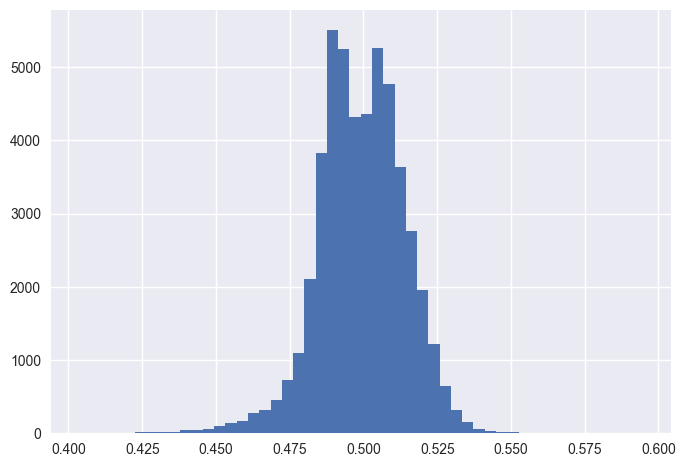

In [26]:
plt.hist(pred, bins = 50)
plt.show()

## Out-Sample Prediction and Forward Testing

In [27]:
test

,price,spread,returns,dir,sma,boll,min,max,mom,vol,...,vol_lag1,vol_lag2,vol_lag3,vol_lag4,vol_lag5,dir_lag1,dir_lag2,dir_lag3,dir_lag4,dir_lag5
time,,,,,,,,,,,,,,,,,,,,,
2023-01-01 23:00:00,1.06998,0.00100,-0.00038,0,0.00201,0.74330,-0.00475,0.00107,-0.00015,0.00069,...,0.00068,0.00070,0.00070,0.00070,0.00071,1.00000,0.00000,1.00000,0.00000,1.00000
2023-01-01 23:15:00,1.07000,0.00100,0.00002,1,0.00205,0.72739,-0.00477,0.00106,-0.00008,0.00068,...,0.00069,0.00068,0.00070,0.00070,0.00070,0.00000,1.00000,0.00000,1.00000,0.00000
2023-01-01 23:30:00,1.07008,0.00050,0.00007,1,0.00209,0.74670,-0.00484,0.00098,-0.00010,0.00067,...,0.00068,0.00069,0.00068,0.00070,0.00070,1.00000,0.00000,1.00000,0.00000,1.00000
2023-01-01 23:45:00,1.07057,0.00050,0.00046,1,0.00211,1.02400,-0.00530,0.00052,0.00018,0.00067,...,0.00067,0.00068,0.00069,0.00068,0.00070,1.00000,1.00000,0.00000,1.00000,0.00000
2023-01-02 00:00:00,1.07052,0.00050,-0.00005,0,0.00214,0.95257,-0.00525,0.00057,0.00016,0.00067,...,0.00067,0.00067,0.00068,0.00069,0.00068,1.00000,1.00000,1.00000,0.00000,1.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-29 20:45:00,1.10411,0.00016,-0.00018,0,-0.00178,-1.62916,-0.00001,0.00346,-0.00026,0.00059,...,0.00059,0.00061,0.00060,0.00059,0.00060,0.00000,0.00000,1.00000,0.00000,1.00000
2023-12-29 21:00:00,1.10358,0.00017,-0.00048,0,-0.00177,-2.02317,0.00000,0.00394,-0.00036,0.00057,...,0.00059,0.00059,0.00061,0.00060,0.00059,0.00000,0.00000,0.00000,1.00000,0.00000
2023-12-29 21:15:00,1.10366,0.00015,0.00007,1,-0.00177,-1.83452,-0.00007,0.00387,-0.00020,0.00057,...,0.00057,0.00059,0.00059,0.00061,0.00060,0.00000,0.00000,0.00000,0.00000,1.00000


In [28]:
test_s = (test - mu) / std
test_s

,price,spread,returns,dir,sma,boll,min,max,mom,vol,...,vol_lag1,vol_lag2,vol_lag3,vol_lag4,vol_lag5,dir_lag1,dir_lag2,dir_lag3,dir_lag4,dir_lag5
time,,,,,,,,,,,,,,,,,,,,,
2023-01-01 23:00:00,-0.63244,8.91881,-0.69319,-0.97743,0.84535,0.56078,-1.01176,-0.53168,-0.46223,0.77107,...,0.76219,0.83404,0.83574,0.83718,0.87073,1.02312,-0.97739,1.02316,-0.97739,1.02316
2023-01-01 23:15:00,-0.63218,8.91881,0.03889,1.02308,0.86247,0.54956,-1.01923,-0.53942,-0.25190,0.74793,...,0.77109,0.76221,0.83406,0.83576,0.83721,-0.97739,1.02312,-0.97735,1.02312,-0.97735
2023-01-01 23:30:00,-0.63113,3.58244,0.14105,1.02308,0.87587,0.56318,-1.04909,-0.57038,-0.30196,0.72625,...,0.74795,0.77111,0.76224,0.83408,0.83579,1.02312,-0.97739,1.02316,-0.97739,1.02316
2023-01-01 23:45:00,-0.62471,3.58244,0.83895,1.02308,0.88690,0.75883,-1.23191,-0.75991,0.59949,0.71988,...,0.72627,0.74797,0.77113,0.76226,0.83410,1.02312,1.02312,-0.97735,1.02312,-0.97735
2023-01-02 00:00:00,-0.62537,3.58244,-0.08026,-0.97743,0.89760,0.70844,-1.21326,-0.74058,0.52939,0.71118,...,0.71990,0.72629,0.74799,0.77116,0.76228,1.02312,1.02312,1.02316,-0.97739,1.02316
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-29 20:45:00,-0.18542,-0.04630,-0.32517,-0.97743,-0.62915,-1.11312,0.89020,0.45494,-0.83580,0.42414,...,0.42422,0.46642,0.46479,0.42311,0.44685,-0.97739,-0.97739,1.02316,-0.97739,1.02316
2023-12-29 21:00:00,-0.19236,0.06043,-0.86997,-0.97743,-0.62686,-1.39112,0.89383,0.65429,-1.13705,0.31694,...,0.42416,0.42424,0.46644,0.46481,0.42314,-0.97739,-0.97739,-0.97735,1.02312,-0.97735
2023-12-29 21:15:00,-0.19132,-0.15302,0.13691,1.02308,-0.62478,-1.25801,0.86474,0.62419,-0.62261,0.31768,...,0.31696,0.42418,0.42426,0.46646,0.46483,-0.97739,-0.97739,-0.97735,-0.97739,1.02316


In [29]:
model.evaluate(test_s[col], test["dir"])

777/777 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5136 - loss: 0.6926


[0.6926482915878296, 0.5136374831199646]

In [30]:
pred = model.predict(train_s[col])
pred

1556/1556 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step


array([[0.52310944],
       [0.4968707 ],
       [0.4967576 ],
       ...,
       [0.48413128],
       [0.48192596],
       [0.47797886]], shape=(49782, 1), dtype=float32)

(array([3.000e+00, 3.000e+00, 1.000e+00, 5.000e+00, 7.000e+00, 1.200e+01,
        1.400e+01, 1.800e+01, 2.200e+01, 4.300e+01, 4.400e+01, 6.300e+01,
        1.030e+02, 1.450e+02, 1.640e+02, 2.730e+02, 3.240e+02, 4.600e+02,
        7.230e+02, 1.098e+03, 2.112e+03, 3.833e+03, 5.507e+03, 5.245e+03,
        4.319e+03, 4.361e+03, 5.264e+03, 4.775e+03, 3.637e+03, 2.759e+03,
        1.954e+03, 1.219e+03, 6.400e+02, 3.220e+02, 1.590e+02, 6.300e+01,
        3.700e+01, 1.100e+01, 1.400e+01, 9.000e+00, 2.000e+00, 4.000e+00,
        4.000e+00, 1.000e+00, 1.000e+00, 0.000e+00, 3.000e+00, 0.000e+00,
        1.000e+00, 1.000e+00]),
 array([0.40354434, 0.40736532, 0.41118634, 0.41500732, 0.41882831,
        0.42264932, 0.42647031, 0.4302913 , 0.43411228, 0.4379333 ,
        0.44175428, 0.44557527, 0.44939625, 0.45321727, 0.45703825,
        0.46085924, 0.46468025, 0.46850124, 0.47232223, 0.47614324,
        0.47996423, 0.48378521, 0.48760623, 0.49142721, 0.4952482 ,
        0.49906921, 0.50289017, 0.50

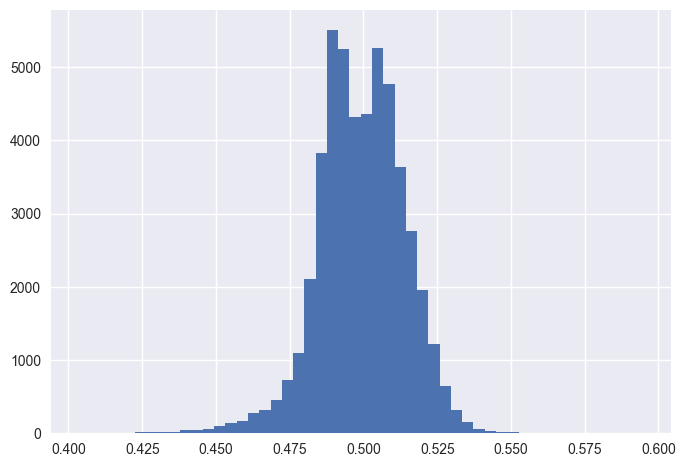

In [31]:
plt.hist(pred, bins = 50)

In [32]:
test['proba'] = model.predict(test_s[col])  

777/777 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step


In [33]:
test["position"] = np.where(test.proba < 0.47, -1, np.nan) # 1. short where proba < 0.47

In [34]:
test["position"] = np.where(test.proba > 0.53, 1, test.position) # 2. long where proba > 0.53

In [35]:
test["hour"] = test.index.hour

In [36]:
test["position"] = np.where(~test.hour.between(12, 16), 0, test.position) # 3. neutral in non-busy hours

In [37]:
test["position"] = test.position.ffill().fillna(0) # 4. in all other cases: hold position

In [38]:
test.position.value_counts(dropna = False)

position
0.00000     23475
1.00000       851
-1.00000      532
Name: count, dtype: int64

In [39]:
test["strategy"] = test["position"] * test["returns"]

In [40]:
test["creturns"] = test["returns"].cumsum().apply(np.exp)
test["cstrategy"] = test["strategy"].cumsum().apply(np.exp)

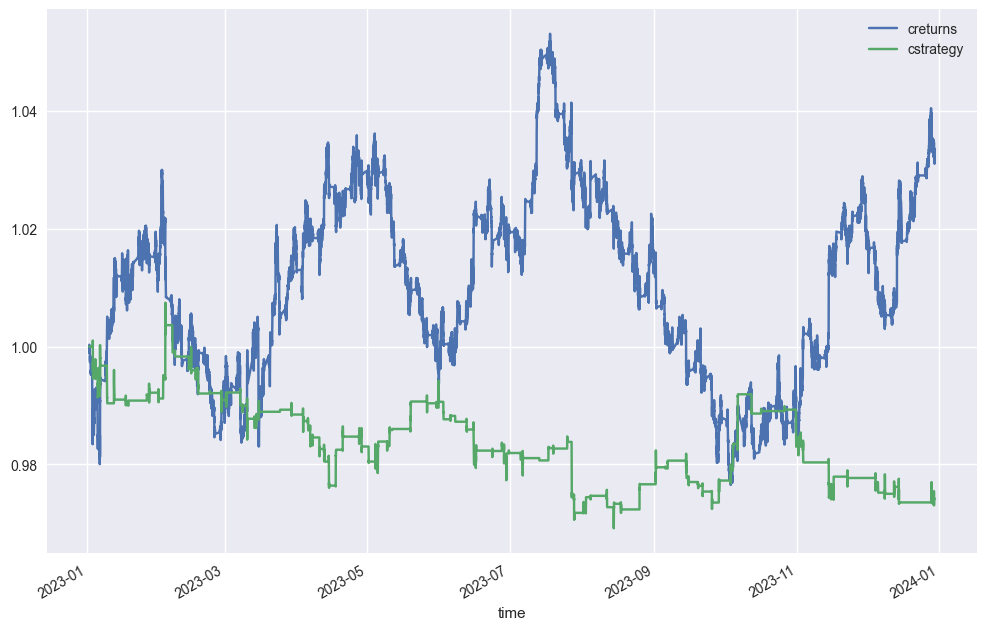

In [41]:
test[["creturns", "cstrategy"]].plot(figsize = (12, 8))
plt.show()

In [42]:
ptc = 0.00005 

In [43]:
test['trades'] = test.position.diff().abs()

In [44]:
test['trades'].value_counts()

trades
0.00000    24621
1.00000      214
2.00000       22
Name: count, dtype: int64

In [45]:
test['strategy_net'] = (test['strategy'] - test['trades'] * ptc).cumsum().apply(np.exp)

In [46]:
test['cstrategy_net'] = (test['strategy'] - test['trades'] * ptc).cumsum().apply(np.exp)

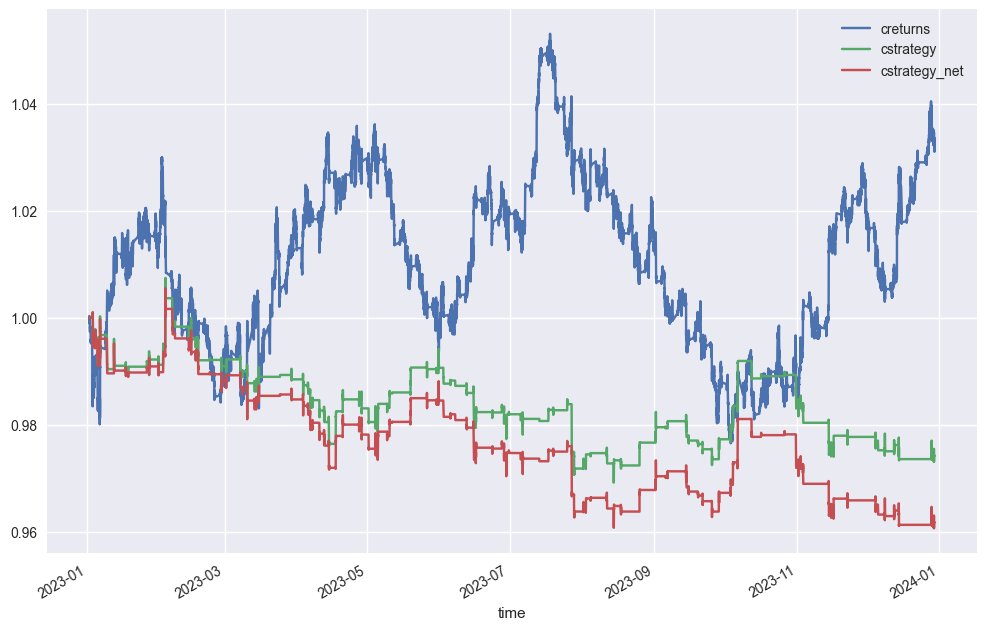

In [47]:
test[['creturns', 'cstrategy', 'cstrategy_net']].plot(figsize = (12, 8))
plt.show()


## XAI Decision Filtering Gate (SHAP)

This section adds a **risk-management gate** in front of the DNN’s trade decisions.

- The DNN produces a position signal (`test["position"]`) at every timestamp.
- A trade only happens when the position **changes** (captured by `test["trades"]`).
- The XAI gate runs **only at trade events** and uses **local SHAP feature importance** to decide whether a *new entry* is sufficiently well-explained.
- **Exits are always allowed** (reduces risk); **entries are filtered** (reduces low-quality / weakly-explained trades).

Outcome: we get a new position series `test["position_xai"]` and a net equity curve `test["cstrategy_net_xai"]` to compare against the baseline `test["cstrategy_net"]`.

In [48]:
# If needed:
# !pip install shap

import shap

# Gate hyperparameters (tune these)
TOP_N = 3
N_BACKGROUND = 200         # SHAP background sample size
N_CALIB = 800             # number of entry/flip events used to calibrate threshold
SHAP_QUANTILE = 0.60      # keep only the strongest ~25% explanations (higher => fewer trades)
PROBA_MARGIN = 0      # additional confidence margin around 0.5 for allowing entries
EXCLUDE_TOP1_PREFIXES = ("dir_",)  # treat these as weak/less-informative top drivers


# Build SHAP explainer on training distribution
background = train_s[col].sample(N_BACKGROUND, random_state=42).values
explainer = shap.DeepExplainer(model, background)


def _extract_shap_vector(shap_values):
    """Return a 1D SHAP vector for the (single) model output."""
    if isinstance(shap_values, list):
        arr = shap_values[0]
    else:
        arr = shap_values
    return np.array(arr).reshape(-1)


def _top_shap_summary(instance_1d, *, top_n=TOP_N):
    """Compute local SHAP summary for one instance."""
    instance_2d = instance_1d.reshape(1, -1)
    shap_values = explainer.shap_values(instance_2d, check_additivity=False)
    sv = _extract_shap_vector(shap_values)

    abs_sv = np.abs(sv)
    top_idx = np.argsort(abs_sv)[::-1][:top_n]
    top_features = [col[int(i)] for i in top_idx]
    top_shap = sv[top_idx]

    return {
        "sv": sv,
        "sv_sum": float(sv.sum()),
        "top_idx": top_idx,
        "top_features": top_features,
        "top_shap": [float(x) for x in top_shap],
        "top_abs": [float(x) for x in abs_sv[top_idx]],
        "top1_abs": float(abs_sv[top_idx[0]]),
    }


def calibrate_shap_threshold(test_df, test_scaled, *, quantile=SHAP_QUANTILE, n_calib=N_CALIB):
    """
    Calibrate an absolute-SHAP threshold from the distribution of top-1 SHAP magnitudes
    on (a sample of) entry/flip events.

    Higher threshold => fewer trades (stricter risk filter).
    """
    # Events where the baseline strategy changes position AND desires a non-zero position
    trade_event = test_df["trades"].fillna(0) > 0
    entry_like = trade_event & (test_df["position"].fillna(0) != 0)
    event_idx = test_df.index[entry_like]

    if len(event_idx) == 0:
        return 0.0

    # Sample for speed
    if len(event_idx) > n_calib:
        event_idx = event_idx[:n_calib]

    top1_abs_list = []
    for idx in event_idx:
        instance = test_scaled.loc[idx, col].values
        summ = _top_shap_summary(instance, top_n=TOP_N)
        top1_abs_list.append(summ["top1_abs"])

    thr = float(np.quantile(np.array(top1_abs_list), quantile))
    return thr


def xai_gate_entry(instance_1d, desired_pos, proba, *, shap_threshold, top_n=TOP_N):
    """
    Decide whether to ALLOW a *new entry* (desired_pos in {-1, +1}) based on local SHAP.

    Checks:
    - confidence: proba must be far enough from 0.5 (PROBA_MARGIN)
    - explanation strength: top-1 |SHAP| must exceed calibrated shap_threshold
    - explanation direction: sum(SHAP) should align with desired direction
    - explanation quality: avoid trivial top driver(s) like dir_lag* (optional)

    Returns: allow(bool), info(dict)
    """
    desired_pos = int(desired_pos)
    proba = float(proba)

    # Confidence check (acts like a second-stage filter)
    if desired_pos == 1:
        proba_ok = proba >= (0.5 + PROBA_MARGIN)
    else:
        proba_ok = proba <= (0.5 - PROBA_MARGIN)

    summ = _top_shap_summary(instance_1d, top_n=top_n)
    sv_sum = summ["sv_sum"]

    direction_ok = (desired_pos == 1 and sv_sum > 0) or (desired_pos == -1 and sv_sum < 0)
    magnitude_ok = summ["top1_abs"] >= float(shap_threshold)

    top1 = summ["top_features"][0]
    top1_ok = not any(top1.startswith(p) for p in EXCLUDE_TOP1_PREFIXES)

    allow = bool(proba_ok and direction_ok and magnitude_ok and top1_ok)

    info = {
        "proba": proba,
        "desired_pos": desired_pos,
        "sv_sum": sv_sum,
        "top_features": summ["top_features"],
        "top_shap": summ["top_shap"],
        "top_abs": summ["top_abs"],
        "top1_abs": summ["top1_abs"],
        "proba_ok": bool(proba_ok),
        "direction_ok": bool(direction_ok),
        "magnitude_ok": bool(magnitude_ok),
        "top1_ok": bool(top1_ok),
        "shap_threshold": float(shap_threshold),
    }
    return allow, info


def format_gate_explanation(prev_pos, desired_pos, final_pos, info, allow):
    tf = info.get("top_features", [])
    ts = info.get("top_shap", [])
    parts = [
        f"prev={prev_pos}, desired={desired_pos}, final={final_pos}",
        f"proba={info.get('proba', np.nan):.3f}, shap_sum={info.get('sv_sum', np.nan):+.4f}, top1_abs={info.get('top1_abs', np.nan):.4f}",
        f"shap_threshold={info.get('shap_threshold', np.nan):.4f}",
        "top features: " + ", ".join([f"{f}({v:+.4f})" for f, v in zip(tf, ts)]),
        f"checks: proba={info.get('proba_ok')} direction={info.get('direction_ok')} magnitude={info.get('magnitude_ok')} top1_ok={info.get('top1_ok')}",
        "DECISION: " + ("ALLOW" if allow else "DENY"),
    ]
    return "\n".join(parts)

c:\Users\RAJ MANE\OneDrive\Desktop\XAI NOVELTY\venv\lib\site-packages\shap\explainers\_deep\deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
c:\Users\RAJ MANE\OneDrive\Desktop\XAI NOVELTY\venv\lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(200, 35))']
  warnings.warn(msg)


In [49]:
# Apply XAI gate only when the baseline strategy would trade
pos_target = test["position"].copy()

# ---------------------------
# FIX FOR DATA LEAKAGE / SNOOPING
# ---------------------------
# DO NOT calibrate SHAP threshold on the test set.
# Instead, calibrate on a "calibration" slice taken from the training period.
# This keeps the test year purely out-of-sample for the XAI gate evaluation.

CALIB_FRAC = 0.20  # last 20% of train used for calibration
calib_start = int(len(train) * (1 - CALIB_FRAC))
calib = train.iloc[calib_start:].copy()
calib_s = (calib - mu) / std

# Build baseline signals on calibration slice (same rules as test baseline)
PROBA_SHORT = 0.47
PROBA_LONG = 0.53
BUSY_HOUR_START = 12
BUSY_HOUR_END = 16

calib["proba"] = model.predict(calib_s[col])
calib["position"] = np.where(calib.proba < PROBA_SHORT, -1, np.nan)
calib["position"] = np.where(calib.proba > PROBA_LONG, 1, calib.position)
calib["hour"] = calib.index.hour
calib["position"] = np.where(~calib.hour.between(BUSY_HOUR_START, BUSY_HOUR_END), 0, calib.position)
calib["position"] = calib.position.ffill().fillna(0)
calib["trades"] = calib.position.diff().abs().fillna(0)

# Calibrate SHAP threshold from entry/flip events in CALIBRATION slice (not test)
SHAP_THRESHOLD = calibrate_shap_threshold(calib, calib_s, quantile=SHAP_QUANTILE, n_calib=N_CALIB)
print("Calibrated SHAP_THRESHOLD (from TRAIN calibration slice):", SHAP_THRESHOLD)

# Construct position_xai sequentially:
# - Exits to 0 are always allowed
# - Entries to +/-1 are filtered by SHAP + confidence checks
# - Flips become: exit (allowed) then optional entry (gated)

position_xai = pd.Series(index=test.index, dtype=float)
position_xai.iloc[0] = float(pos_target.iloc[0])

trade_event = test["trades"].fillna(0) > 0

gate_log = []

for i in range(1, len(test)):
    idx = test.index[i]
    prev = float(position_xai.iloc[i - 1])
    desired = float(pos_target.iloc[i])

    # Default: hold
    final_pos = prev
    action = "hold"
    allow = True

    proba = float(test.loc[idx, "proba"])
    info = {"proba": proba, "desired_pos": int(desired), "sv_sum": np.nan, "top_features": [], "top_shap": [], "top_abs": [], "top1_abs": np.nan, "proba_ok": True, "direction_ok": True, "magnitude_ok": True, "top1_ok": True, "shap_threshold": float(SHAP_THRESHOLD)}

    if trade_event.iloc[i]:
        # Model wants to change position here
        if desired == 0:
            action = "exit"
            final_pos = 0.0
            allow = True

        elif prev != 0 and np.sign(prev) != np.sign(desired):
            # Flip: always exit; entry is gated
            action = "flip"
            instance = test_s.loc[idx, col].values
            allow_entry, info = xai_gate_entry(instance, int(desired), proba, shap_threshold=SHAP_THRESHOLD, top_n=TOP_N)
            allow = allow_entry
            final_pos = float(desired) if allow_entry else 0.0

        else:
            # Entry from flat, or re-entry after being flat
            action = "entry"
            instance = test_s.loc[idx, col].values
            allow_entry, info = xai_gate_entry(instance, int(desired), proba, shap_threshold=SHAP_THRESHOLD, top_n=TOP_N)
            allow = allow_entry
            final_pos = float(desired) if allow_entry else prev

    position_xai.iloc[i] = final_pos

    if trade_event.iloc[i]:
        gate_log.append({
            "time": idx,
            "action": action,
            "prev_pos": prev,
            "desired_pos": desired,
            "final_pos": final_pos,
            "allow": bool(allow),
            "proba": info.get("proba", np.nan),
            "sv_sum": info.get("sv_sum", np.nan),
            "top1": info.get("top_features", [None])[0] if info.get("top_features") else None,
            "top1_abs": info.get("top1_abs", np.nan),
            "top1_shap": info.get("top_shap", [np.nan])[0] if info.get("top_shap") else np.nan,
            "proba_ok": info.get("proba_ok", True),
            "direction_ok": info.get("direction_ok", True),
            "magnitude_ok": info.get("magnitude_ok", True),
            "top1_ok": info.get("top1_ok", True),
            "shap_threshold": info.get("shap_threshold", np.nan),
            "explanation": format_gate_explanation(prev, desired, final_pos, info, allow),
        })

# Attach to test
position_xai = position_xai.ffill().fillna(0)
test["position_xai"] = position_xai

# Trades and performance with gate
test["trades_xai"] = test["position_xai"].diff().abs().fillna(0)
test["strategy_xai"] = test["position_xai"] * test["returns"]
test["cstrategy_xai"] = test["strategy_xai"].cumsum().apply(np.exp)
test["cstrategy_net_xai"] = (test["strategy_xai"] - test["trades_xai"] * ptc).cumsum().apply(np.exp)

# Gate log table
gate_log_df = pd.DataFrame(gate_log).set_index("time")
gate_log_df.head()

312/312 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


c:\Users\RAJ MANE\OneDrive\Desktop\XAI NOVELTY\venv\lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(400, 35))']
  warnings.warn(msg)


Calibrated SHAP_THRESHOLD (from TRAIN calibration slice): 0.014206051546036857


,action,prev_pos,desired_pos,final_pos,allow,proba,sv_sum,top1,top1_abs,top1_shap,proba_ok,direction_ok,magnitude_ok,top1_ok,shap_threshold,explanation
time,,,,,,,,,,,,,,,,
2023-01-03 12:45:00,entry,0.00000,-1.00000,0.00000,False,0.46511,-0.03508,mom_lag1,0.01123,-0.01123,True,True,False,True,0.01421,"prev=0.0, desired=-1.0, final=0.0\nproba=0.465..."
2023-01-03 15:00:00,entry,0.00000,1.00000,0.00000,False,0.53268,0.03249,mom_lag2,0.01113,0.01113,True,True,False,True,0.01421,"prev=0.0, desired=1.0, final=0.0\nproba=0.533,..."
2023-01-03 17:00:00,exit,0.00000,0.00000,0.00000,True,0.46573,NaN,None,NaN,NaN,True,True,True,True,0.01421,"prev=0.0, desired=0.0, final=0.0\nproba=0.466,..."
2023-01-04 12:30:00,entry,0.00000,1.00000,0.00000,False,0.53059,0.03040,dir_lag1,0.00721,0.00721,True,True,False,False,0.01421,"prev=0.0, desired=1.0, final=0.0\nproba=0.531,..."
2023-01-04 16:45:00,entry,0.00000,-1.00000,0.00000,False,0.45168,-0.04851,vol_lag3,0.00599,-0.00599,True,True,False,True,0.01421,"prev=0.0, desired=-1.0, final=0.0\nproba=0.452..."


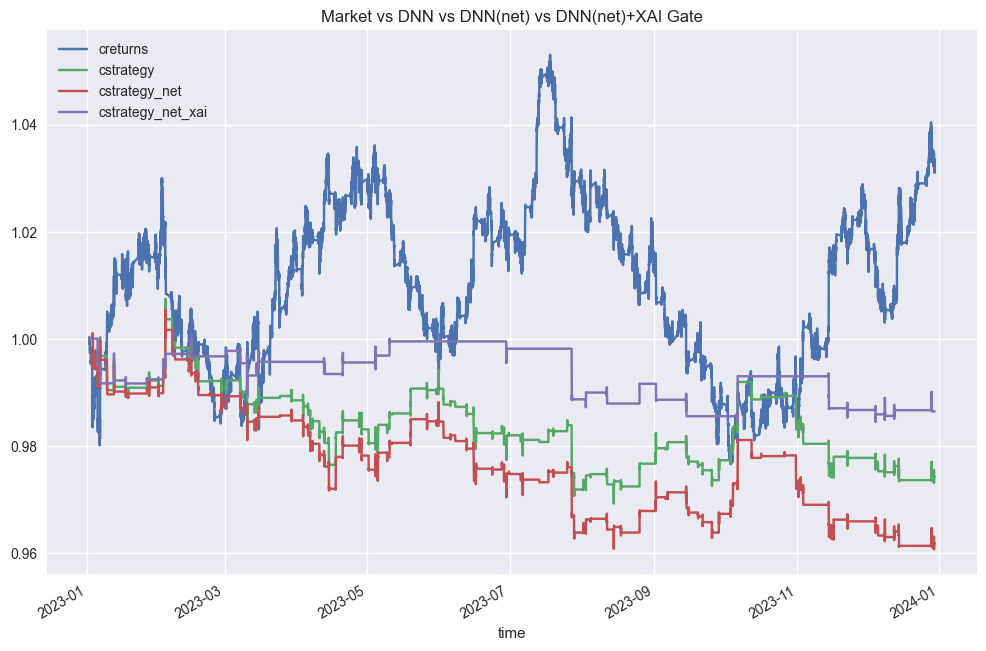

Baseline (net) ending value: 0.9617509598323032
XAI-gated (net) ending value: 0.9864169924939047
Baseline orders (sum abs pos change): 258.0
XAI orders (sum abs pos change): 68.0
Baseline trade events (bars with orders): 236
XAI trade events (bars with orders): 66
Gate evaluated events: 236
Gate allowed events: 141
Gate denied events: 95
Order reduction vs baseline: 73.64%


In [50]:
# Compare baseline vs XAI-gated strategy (net of trading costs)
compare_cols = ["creturns", "cstrategy", "cstrategy_net", "cstrategy_net_xai"]
test[compare_cols].plot(figsize=(12, 8))
plt.title("Market vs DNN vs DNN(net) vs DNN(net)+XAI Gate")
plt.show()

# Trade counts and gate stats
baseline_orders = float(test["trades"].fillna(0).sum())
xai_orders = float(test["trades_xai"].fillna(0).sum())
baseline_trade_events = int((test["trades"].fillna(0) > 0).sum())
xai_trade_events = int((test["trades_xai"].fillna(0) > 0).sum())

allowed = int(gate_log_df["allow"].sum())
denied = int((~gate_log_df["allow"]).sum())

print("Baseline (net) ending value:", float(test["cstrategy_net"].iloc[-1]))
print("XAI-gated (net) ending value:", float(test["cstrategy_net_xai"].iloc[-1]))
print("Baseline orders (sum abs pos change):", baseline_orders)
print("XAI orders (sum abs pos change):", xai_orders)
print("Baseline trade events (bars with orders):", baseline_trade_events)
print("XAI trade events (bars with orders):", xai_trade_events)
print("Gate evaluated events:", len(gate_log_df))
print("Gate allowed events:", allowed)
print("Gate denied events:", denied)

# How XAI acts as risk management
reduction = 0 if baseline_orders == 0 else 1 - (xai_orders / baseline_orders)
print("Order reduction vs baseline:", f"{reduction:.2%}")

In [51]:
# Show sample trade decisions with explanations

# Sample a few allowed and denied events (if available)
allowed_samples = gate_log_df[gate_log_df["allow"]].head(5)
denied_samples = gate_log_df[~gate_log_df["allow"]].head(5)

print("\n--- Sample ALLOWED decisions (first 5) ---")
for t, row in allowed_samples.iterrows():
    print("\nTime:", t)
    print(row["explanation"])

print("\n--- Sample DENIED decisions (first 5) ---")
for t, row in denied_samples.iterrows():
    print("\nTime:", t)
    
    print(row["explanation"])

# Compact table view
cols_view = ["action", "prev_pos", "desired_pos", "final_pos", "allow", "proba", "sv_sum", "top1", "top1_shap"]
gate_log_df[cols_view].head(20)


--- Sample ALLOWED decisions (first 5) ---

Time: 2023-01-03 17:00:00
prev=0.0, desired=0.0, final=0.0
proba=0.466, shap_sum=+nan, top1_abs=nan
shap_threshold=0.0142
top features: 
checks: proba=True direction=True magnitude=True top1_ok=True
DECISION: ALLOW

Time: 2023-01-04 17:00:00
prev=0.0, desired=0.0, final=0.0
proba=0.479, shap_sum=+nan, top1_abs=nan
shap_threshold=0.0142
top features: 
checks: proba=True direction=True magnitude=True top1_ok=True
DECISION: ALLOW

Time: 2023-01-05 13:45:00
prev=0.0, desired=1.0, final=1.0
proba=0.533, shap_sum=+0.0325, top1_abs=0.0147
shap_threshold=0.0142
top features: mom_lag1(+0.0147), boll_lag1(+0.0102), boll_lag2(+0.0051)
checks: proba=True direction=True magnitude=True top1_ok=True
DECISION: ALLOW

Time: 2023-01-05 17:00:00
prev=1.0, desired=0.0, final=0.0
proba=0.504, shap_sum=+nan, top1_abs=nan
shap_threshold=0.0142
top features: 
checks: proba=True direction=True magnitude=True top1_ok=True
DECISION: ALLOW

Time: 2023-01-06 15:30:00
pr

,action,prev_pos,desired_pos,final_pos,allow,proba,sv_sum,top1,top1_shap
time,,,,,,,,,
2023-01-03 12:45:00,entry,0.00000,-1.00000,0.00000,False,0.46511,-0.03508,mom_lag1,-0.01123
2023-01-03 15:00:00,entry,0.00000,1.00000,0.00000,False,0.53268,0.03249,mom_lag2,0.01113
2023-01-03 17:00:00,exit,0.00000,0.00000,0.00000,True,0.46573,NaN,None,NaN
2023-01-04 12:30:00,entry,0.00000,1.00000,0.00000,False,0.53059,0.03040,dir_lag1,0.00721
2023-01-04 16:45:00,entry,0.00000,-1.00000,0.00000,False,0.45168,-0.04851,vol_lag3,-0.00599
2023-01-04 17:00:00,exit,0.00000,0.00000,0.00000,True,0.47864,NaN,None,NaN
2023-01-05 13:45:00,entry,0.00000,1.00000,1.00000,True,0.53267,0.03248,mom_lag1,0.01471
2023-01-05 17:00:00,exit,1.00000,0.00000,0.00000,True,0.50381,NaN,None,NaN
2023-01-06 12:15:00,entry,0.00000,1.00000,0.00000,False,0.53075,0.03056,mom_lag1,0.00853


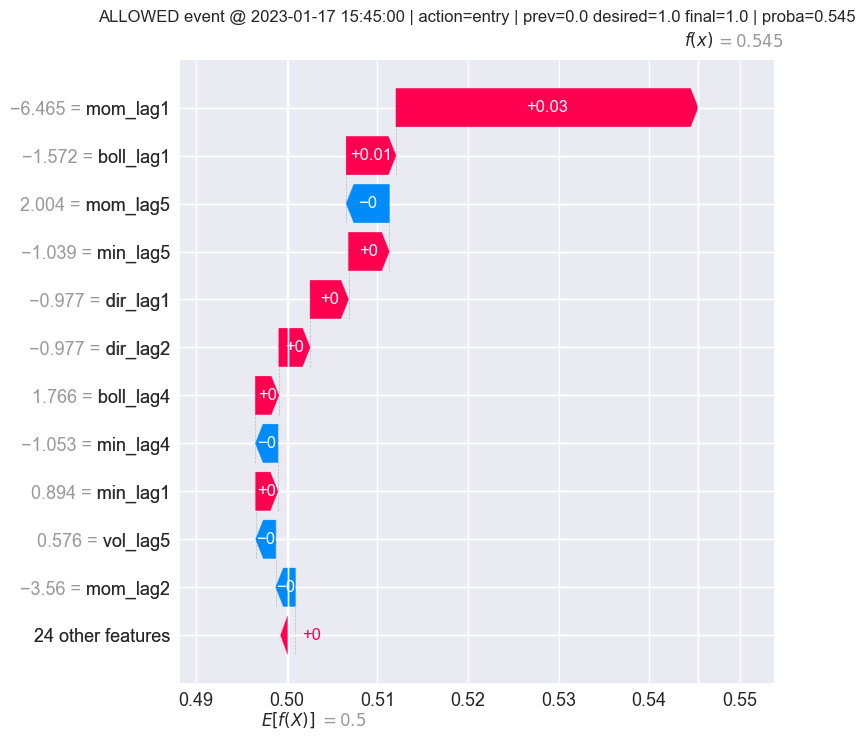


--- Explanation (ALLOWED entry/flip) ---
prev=0.0, desired=1.0, final=1.0
proba=0.545, shap_sum=+0.0452, top1_abs=0.0333
shap_threshold=0.0142
top features: mom_lag1(+0.0333), boll_lag1(+0.0055), mom_lag5(-0.0048)
checks: proba=True direction=True magnitude=True top1_ok=True
DECISION: ALLOW


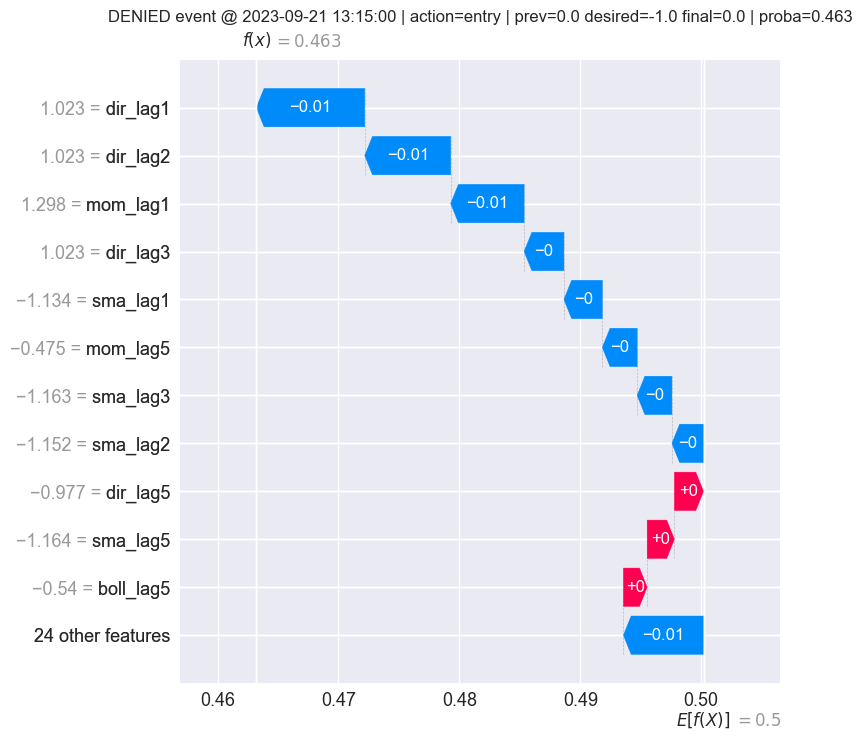


--- Explanation (DENIED entry/flip) ---
prev=0.0, desired=-1.0, final=0.0
proba=0.463, shap_sum=-0.0370, top1_abs=0.0090
shap_threshold=0.0142
top features: dir_lag1(-0.0090), dir_lag2(-0.0071), mom_lag1(-0.0061)
checks: proba=True direction=True magnitude=False top1_ok=False
DECISION: DENY


In [52]:
# Waterfall plots: one random ALLOWED entry/flip and one random DENIED entry/flip

def _get_expected_value(exp):
    ev = getattr(exp, "expected_value", 0.0)
    if isinstance(ev, (list, tuple, np.ndarray)):
        ev = ev[0]
    return float(np.array(ev).reshape(()))


def waterfall_for_event(event_time, label):
    x = test_s.loc[event_time, col].values
    shap_values = explainer.shap_values(x.reshape(1, -1), check_additivity=False)
    sv = _extract_shap_vector(shap_values)
    base = _get_expected_value(explainer)

    exp = shap.Explanation(
        values=sv,
        base_values=base,
        data=x,
        feature_names=col,
    )

    meta = gate_log_df.loc[event_time]
    title = (
        f"{label} event @ {event_time} | action={meta['action']} | "
        f"prev={meta['prev_pos']} desired={meta['desired_pos']} final={meta['final_pos']} | proba={meta['proba']:.3f}"
    )

    plt.figure(figsize=(10, 5))
    shap.plots.waterfall(exp, max_display=12, show=False)
    plt.title(title)
    plt.tight_layout()
    plt.show()


rng = np.random.default_rng(42)

# We want cases where the gate actually matters: entries or flips (not exits)
entry_like = gate_log_df["action"].isin(["entry", "flip"]) & (gate_log_df["desired_pos"].astype(float) != 0)

allowed_candidates = gate_log_df[entry_like & (gate_log_df["allow"])].index

denied_candidates = gate_log_df[entry_like & (~gate_log_df["allow"])].index

if len(allowed_candidates) > 0:
    t_allowed = allowed_candidates[rng.integers(0, len(allowed_candidates))]
    waterfall_for_event(t_allowed, "ALLOWED")
    print("\n--- Explanation (ALLOWED entry/flip) ---")
    print(gate_log_df.loc[t_allowed, "explanation"])
else:
    print("No ALLOWED entry/flip events available to plot.")

if len(denied_candidates) > 0:
    t_denied = denied_candidates[rng.integers(0, len(denied_candidates))]
    waterfall_for_event(t_denied, "DENIED")
    print("\n--- Explanation (DENIED entry/flip) ---")
    print(gate_log_df.loc[t_denied, "explanation"])
else:
    print("No DENIED entry/flip events available to plot.")

## Additional XAI Visualisations (MSc-ready)

This block produces four groups of figures:

1) **Global feature importance** (SHAP beeswarm + bar)
2) **Local explanations** (already shown above via waterfall plots)
3) **Gate behavior summary** (allowed vs denied distributions + top-driver frequency)
4) **Regime / time stability** (rolling mean absolute SHAP for top features)

Notes:
- SHAP for deep models is compute-heavy. These cells intentionally compute SHAP on a **sample** to keep runtime practical.
- To make results reproducible, a fixed RNG seed is used for sampling.

In [53]:
# ---- SHAP sampling utilities (used by multiple plots) ----

RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)

# Control how many points to explain (trade-off: quality vs runtime)
GLOBAL_SHAP_SAMPLES = 1200      # for global beeswarm+bar
REGIME_SHAP_SAMPLES = 2000      # for rolling stability
SHAP_BATCH = 200                # batch size for explainer

# Choose where to sample from:
# - For "global" interpretation across all timestamps, sample from test_s.
# - For "trade-centric" interpretation, sample from trade events only.
USE_TRADE_EVENTS_FOR_GLOBAL = False


def _extract_shap_matrix(shap_values):
    """Return a (n_samples, n_features) matrix from DeepExplainer output."""
    if isinstance(shap_values, list):
        arr = shap_values[0]
    else:
        arr = shap_values
    return np.array(arr)


def compute_shap_for_index(index, *, batch_size=SHAP_BATCH):
    """
    Compute SHAP values for rows in `index` using `test_s[col]` and the global `explainer`.
    Returns: X (n, d), S (n, d)
    """
    X = test_s.loc[index, col].values
    S_chunks = []

    for start in range(0, len(index), batch_size):
        end = min(start + batch_size, len(index))
        xb = X[start:end]
        sv = explainer.shap_values(xb, check_additivity=False)
        S_chunks.append(_extract_shap_matrix(sv))

    S = np.vstack(S_chunks) if len(S_chunks) else np.empty((0, len(col)))
    return X, S


def _sample_index_from_pool(pool_index, n):
    pool_index = np.array(pool_index)
    if len(pool_index) <= n:
        return pool_index
    take = rng.choice(len(pool_index), size=n, replace=False)
    return pool_index[take]


# Build sampling pools
trade_event_idx = gate_log_df.index  # when the baseline strategy changed position
all_test_idx = test.index

global_pool = trade_event_idx if USE_TRADE_EVENTS_FOR_GLOBAL else all_test_idx

# Samples for plots
idx_global = _sample_index_from_pool(global_pool, GLOBAL_SHAP_SAMPLES)
idx_regime = _sample_index_from_pool(trade_event_idx, REGIME_SHAP_SAMPLES)

print("Global SHAP sample size:", len(idx_global), "(trade-centric:" , USE_TRADE_EVENTS_FOR_GLOBAL, ")")
print("Regime SHAP sample size:", len(idx_regime), "(trade-event-only)")

Global SHAP sample size: 1200 (trade-centric: False )
Regime SHAP sample size: 236 (trade-event-only)


In [54]:
model

<Sequential name=sequential, built=True>

In [55]:
mu

price        1.11827
spread       0.00016
returns     -0.00000
dir          0.48859
sma         -0.00016
boll        -0.05151
min         -0.00223
max          0.00236
mom         -0.00000
vol          0.00048
sma_lag1    -0.00016
sma_lag2    -0.00016
sma_lag3    -0.00016
sma_lag4    -0.00016
sma_lag5    -0.00016
boll_lag1   -0.05155
boll_lag2   -0.05159
boll_lag3   -0.05164
boll_lag4   -0.05168
boll_lag5   -0.05173
min_lag1    -0.00223
min_lag2    -0.00223
min_lag3    -0.00223
min_lag4    -0.00223
min_lag5    -0.00223
max_lag1     0.00236
max_lag2     0.00236
max_lag3     0.00236
max_lag4     0.00236
max_lag5     0.00236
mom_lag1    -0.00000
mom_lag2    -0.00000
mom_lag3    -0.00000
mom_lag4    -0.00000
mom_lag5    -0.00000
vol_lag1     0.00048
vol_lag2     0.00048
vol_lag3     0.00048
vol_lag4     0.00048
vol_lag5     0.00048
dir_lag1     0.48857
dir_lag2     0.48857
dir_lag3     0.48855
dir_lag4     0.48857
dir_lag5     0.48855
dtype: float64

In [56]:
std

price       0.07635
spread      0.00009
returns     0.00055
dir         0.49987
sma         0.00257
boll        1.41732
min         0.00249
max         0.00242
mom         0.00031
vol         0.00026
sma_lag1    0.00257
sma_lag2    0.00257
sma_lag3    0.00257
sma_lag4    0.00257
sma_lag5    0.00257
boll_lag1   1.41732
boll_lag2   1.41732
boll_lag3   1.41732
boll_lag4   1.41732
boll_lag5   1.41732
min_lag1    0.00249
min_lag2    0.00249
min_lag3    0.00249
min_lag4    0.00249
min_lag5    0.00249
max_lag1    0.00242
max_lag2    0.00242
max_lag3    0.00242
max_lag4    0.00242
max_lag5    0.00242
mom_lag1    0.00031
mom_lag2    0.00031
mom_lag3    0.00031
mom_lag4    0.00031
mom_lag5    0.00031
vol_lag1    0.00026
vol_lag2    0.00026
vol_lag3    0.00026
vol_lag4    0.00026
vol_lag5    0.00026
dir_lag1    0.49987
dir_lag2    0.49987
dir_lag3    0.49987
dir_lag4    0.49987
dir_lag5    0.49987
dtype: float64

In [57]:
model.save("DNN_model.keras")

In [58]:
import pickle

In [59]:
params = {"mu":mu, "std":std}

In [60]:
params

{'mu': price        1.11827
 spread       0.00016
 returns     -0.00000
 dir          0.48859
 sma         -0.00016
 boll        -0.05151
 min         -0.00223
 max          0.00236
 mom         -0.00000
 vol          0.00048
 sma_lag1    -0.00016
 sma_lag2    -0.00016
 sma_lag3    -0.00016
 sma_lag4    -0.00016
 sma_lag5    -0.00016
 boll_lag1   -0.05155
 boll_lag2   -0.05159
 boll_lag3   -0.05164
 boll_lag4   -0.05168
 boll_lag5   -0.05173
 min_lag1    -0.00223
 min_lag2    -0.00223
 min_lag3    -0.00223
 min_lag4    -0.00223
 min_lag5    -0.00223
 max_lag1     0.00236
 max_lag2     0.00236
 max_lag3     0.00236
 max_lag4     0.00236
 max_lag5     0.00236
 mom_lag1    -0.00000
 mom_lag2    -0.00000
 mom_lag3    -0.00000
 mom_lag4    -0.00000
 mom_lag5    -0.00000
 vol_lag1     0.00048
 vol_lag2     0.00048
 vol_lag3     0.00048
 vol_lag4     0.00048
 vol_lag5     0.00048
 dir_lag1     0.48857
 dir_lag2     0.48857
 dir_lag3     0.48855
 dir_lag4     0.48857
 dir_lag5     0.48855
 dty

In [61]:
pickle.dump(params, open("params.pkl", "wb"))

In [62]:
summary = pd.DataFrame(
    {
        "ending_value_net": [
            float(test["cstrategy_net"].iloc[-1]),
            float(test["cstrategy_net_xai"].iloc[-1]),
        ],
        "orders_sum_abs_pos_change": [
            float(test["trades"].fillna(0).sum()),
            float(test["trades_xai"].fillna(0).sum()),
        ],
        "trade_event_bars": [
            int((test["trades"].fillna(0) > 0).sum()),
            int((test["trades_xai"].fillna(0) > 0).sum()),
        ],
        # Better cost reporting:
        "total_trade_cost_paid": [
            float((test["trades"].fillna(0) * ptc).sum()),
            float((test["trades_xai"].fillna(0) * ptc).sum()),
        ],
    },
    index=["baseline", "xai_gated"],
)

summary["avg_cost_per_trade_event"] = (
    summary["total_trade_cost_paid"] / summary["trade_event_bars"].replace(0, np.nan)
)

summary["avg_cost_per_order_unit"] = (
    summary["total_trade_cost_paid"] / summary["orders_sum_abs_pos_change"].replace(0, np.nan)
)

summary["order_reduction_vs_baseline"] = np.nan
summary.loc["xai_gated", "order_reduction_vs_baseline"] = (
    1 - summary.loc["xai_gated", "orders_sum_abs_pos_change"] / summary.loc["baseline", "orders_sum_abs_pos_change"]
)

summary

,ending_value_net,orders_sum_abs_pos_change,trade_event_bars,total_trade_cost_paid,avg_cost_per_trade_event,avg_cost_per_order_unit,order_reduction_vs_baseline
baseline,0.96175,258.00000,236,0.01290,0.00005,0.00005,NaN
xai_gated,0.98642,68.00000,66,0.00340,0.00005,0.00005,0.73643


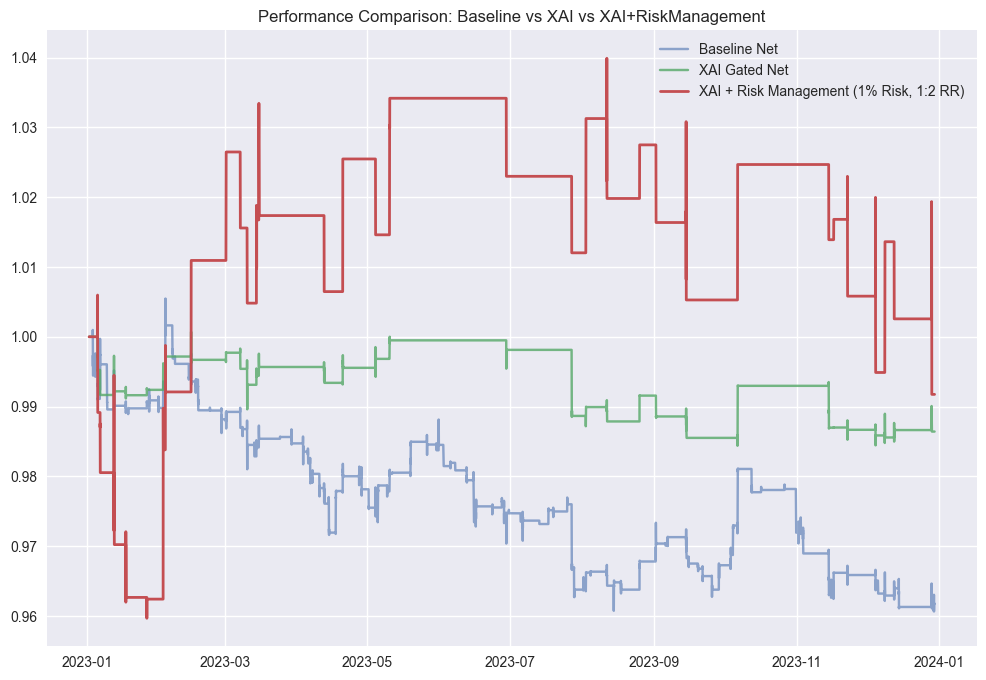


--- Risk Management System Performance ---
Final Capital: 99174.54
Total Trades: 34
Win Rate: 44.12%
Avg Win: 1221.31
Avg Loss: -1007.64
Risk:Reward Realized: 1.21


In [63]:

# -------------------------------------------------------------------------------------
# RISK MANAGEMENT SYSTEM IMPLEMENTATION
# -------------------------------------------------------------------------------------
# Logic:
# 1. Capital: 100,000
# 2. Risk per Trade: 1% of Capital
# 3. Position Sizing: Risk Amount / (Entry - SL)
# 4. Target: 1:2 Risk:Reward Ratio
# 5. Stop Loss: Dynamic based on Volatility (2 * Volatility * Price) - Proxy for "Quant" approach

INITIAL_CAPITAL = 100000
RISK_PCT = 0.01
REWARD_RATIO = 2.0
LEVERAGE_CAP = 30 # Safety cap
PTC = 0.00005 # Transaction cost rate from previous cells

class RiskManagedBacktest:
    def __init__(self, df, signal_col="position_xai", price_col="price", vol_col="vol"):
        self.df = df
        self.signal_col = signal_col
        self.price_col = price_col
        self.vol_col = vol_col
        self.capital = INITIAL_CAPITAL
        self.equity = [INITIAL_CAPITAL]
        self.trades_list = []
        
    def run(self):
        # State
        position = 0 # 0, 1, -1
        entry_price = 0.0
        stop_loss = 0.0
        take_profit = 0.0
        qty = 0
        
        # We start from index 1 to allow looking at previous signal
        for i in range(1, len(self.df)):
            idx = self.df.index[i]
            
            # Current Market Data
            current_price = self.df[self.price_col].iloc[i]
            current_vol = self.df[self.vol_col].iloc[i]
            current_signal = self.df[self.signal_col].iloc[i]
            
            # Previous Signal (to detect changes)
            prev_signal = self.df[self.signal_col].iloc[i-1]
            
            # 1. MANAGE EXISTING TRADE (SL/TP)
            if position != 0:
                # Check for SL Hit (Assume hit at SL level)
                sl_hit = (position == 1 and current_price <= stop_loss) or \
                         (position == -1 and current_price >= stop_loss)
                
                # Check for TP Hit (Assume hit at TP level)
                tp_hit = (position == 1 and current_price >= take_profit) or \
                         (position == -1 and current_price <= take_profit)
                
                # Check for Signal Reversal/Exit (XAI Strategy says get out)
                # Exit if signal goes to 0 or flips direction
                sig_exit = (current_signal == 0) or (current_signal != position)
                
                exit_price = None
                exit_reason = None
                
                if sl_hit:
                    exit_price = stop_loss
                    exit_reason = "SL"
                elif tp_hit:
                    exit_price = take_profit
                    exit_reason = "TP"
                elif sig_exit:
                    exit_price = current_price
                    exit_reason = "Signal"
                
                if exit_price is not None:
                    # Calculate PnL
                    # Gross PnL
                    trade_pnl = (exit_price - entry_price) * qty * position
                    # Transaction Costs (Entry + Exit) ~ Estimated
                    commission = (qty * entry_price * PTC) + (qty * exit_price * PTC)
                    
                    net_pnl = trade_pnl - commission
                    self.capital += net_pnl
                    
                    self.trades_list.append({
                        "Entry Time": entry_time,
                        "Exit Time": idx,
                        "Type": position,
                        "Entry Price": entry_price,
                        "Exit Price": exit_price,
                        "Reason": exit_reason,
                        "PnL": net_pnl,
                        "Return %": (net_pnl / (qty * entry_price)) * 100
                    })
                    
                    # Reset State
                    position = 0
                    qty = 0
            
            # 2. CHECK FOR NEW ENTRY
            # Only enter if currently flat AND signal has CHANGED to a new active state
            # (Matches XAI Gate logic: trade on events)
            if position == 0:
                if current_signal != 0 and current_signal != prev_signal:
                    # Logic to calculate Size
                    risk_amt = self.capital * RISK_PCT
                    
                    # Determine SL Distance
                    # Use 2 * Volatility (StdDev of Returns) * Price as proxy for ATR/Swing
                    # If Vol is too low, set min floor
                    sl_dist = current_price * current_vol * 2.0
                    if sl_dist < (current_price * 0.0005): # Min 5 pips approx
                        sl_dist = current_price * 0.0005
                        
                    if current_signal == 1:
                        stop_loss = current_price - sl_dist
                        take_profit = current_price + (sl_dist * REWARD_RATIO)
                    else:
                        stop_loss = current_price + sl_dist
                        take_profit = current_price - (sl_dist * REWARD_RATIO)
                        
                    # Calculate Quantity
                    # Risk = Qty * |Entry - SL|
                    # Qty = Risk / |Entry - SL|
                    if sl_dist > 0:
                        qty = risk_amt / sl_dist
                    else:
                        qty = 0
                        
                    # Leverage Check (Optional)
                    notional = qty * current_price
                    if notional > (self.capital * LEVERAGE_CAP):
                        qty = (self.capital * LEVERAGE_CAP) / current_price
                        
                    position = current_signal
                    entry_price = current_price
                    entry_time = idx
            
            # Record Equity Curve
            # Mark-to-market equity
            open_pnl = 0
            if position != 0:
                open_pnl = (current_price - entry_price) * qty * position
            
            self.equity.append(self.capital + open_pnl)
            
        return pd.Series(self.equity, index=self.df.index[len(self.df)-len(self.equity):])

# Run the RM Backtest
rm_backtest = RiskManagedBacktest(test, signal_col="position_xai")
test['equity_rm'] = rm_backtest.run()

# Normalize for comparison plot (Start at 1.0 like others)
test['cstrategy_rm_norm'] = test['equity_rm'] / INITIAL_CAPITAL

# Plotting Comparison
plt.figure(figsize=(12, 8))
plt.plot(test['cstrategy_net'], label='Baseline Net', alpha=0.6)
plt.plot(test['cstrategy_net_xai'], label='XAI Gated Net', alpha=0.8)
plt.plot(test['cstrategy_rm_norm'], label='XAI + Risk Management (1% Risk, 1:2 RR)', linewidth=2)
plt.title("Performance Comparison: Baseline vs XAI vs XAI+RiskManagement")
plt.legend()
plt.show()

# Statistics
trades_df = pd.DataFrame(rm_backtest.trades_list)
print("\n--- Risk Management System Performance ---")
print(f"Final Capital: {test['equity_rm'].iloc[-1]:.2f}")
print(f"Total Trades: {len(trades_df)}")
if len(trades_df) > 0:
    win_rate = len(trades_df[trades_df['PnL'] > 0]) / len(trades_df)
    avg_win = trades_df[trades_df['PnL'] > 0]['PnL'].mean()
    avg_loss = trades_df[trades_df['PnL'] <= 0]['PnL'].mean()
    print(f"Win Rate: {win_rate:.2%}")
    print(f"Avg Win: {avg_win:.2f}")
    print(f"Avg Loss: {avg_loss:.2f}")
    print(f"Risk:Reward Realized: {abs(avg_win/avg_loss):.2f}")
else:
    print("No trades generated.")
